## 1. Import des bibliothèques

In [1]:
from pathlib import Path
import random
import hashlib

from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import sys
import torch
from torchvision import models
from torchvision.io import read_image, ImageReadMode
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import adjusted_rand_score
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import time


In [2]:
debut_notebook = time.perf_counter()

In [3]:
dossier_dataset = Path("mri_dataset_brain_cancer_oc")

print("Le dossier existe :", dossier_dataset.is_dir())

Le dossier existe : True


## Etape 1: Import des données et exploration des radios

Le dataset est organisé en deux répertoires: Un avec label et un sans label

normal : Radio labelisée comme présentant une tumeur cancereuse
cancer : Radio labelisée comme présentant une tumeur cancereuse

Le fichier .txt décerit le contenu du dataset: **1 500 images**, au format **JPEG**, dont 100 étiquetées et 1 400 sans label.

In [4]:
chemins_images = sorted(dossier_dataset.rglob("*.jpg"))

print("Nombre total d'images :", len(chemins_images))
print("Nombre annoncé dans le descriptif :", 1500)
print("Écart au descriptif :", len(chemins_images) - 1500)

Nombre total d'images : 1506
Nombre annoncé dans le descriptif : 1500
Écart au descriptif : 6


Comptons maintenant les images de chaque dossier.


In [5]:
dossiers = ["avec_labels/cancer", "avec_labels/normal", "sans_label"]
effectifs = []

for dossier in dossiers:
    fichiers = list((dossier_dataset / dossier).glob("*.jpg"))
    effectifs.append({
        "Dossier": dossier,
        "Nombre d'images": len(fichiers),
    })

tableau_effectifs = pd.DataFrame(effectifs)
display(tableau_effectifs)

,Dossier,Nombre d'images
0,avec_labels/cancer,50
1,avec_labels/normal,50
2,sans_label,1406


Ouverture d'une image et lecture de ses propriétés

In [6]:
chemin_exemple = chemins_images[0]

with Image.open(chemin_exemple) as image:
    print("Fichier :", chemin_exemple.name)
    print("Dossier :", chemin_exemple.parent.relative_to(dossier_dataset))
    print("Format :", image.format)
    print("Largeur :", image.width, "pixels")
    print("Hauteur :", image.height, "pixels")
    print("Mode de couleur :", image.mode)
    print("Canaux :", image.getbands())
    pixels = np.array(image)

print("Forme du tableau NumPy :", pixels.shape)

Fichier : 05340cd4-3bb2-459d-9937-bf27d52d8351.jpg
Dossier : avec_labels/cancer
Format : JPEG
Largeur : 512 pixels
Hauteur : 512 pixels
Mode de couleur : RGB
Canaux : ('R', 'G', 'B')
Forme du tableau NumPy : (512, 512, 3)


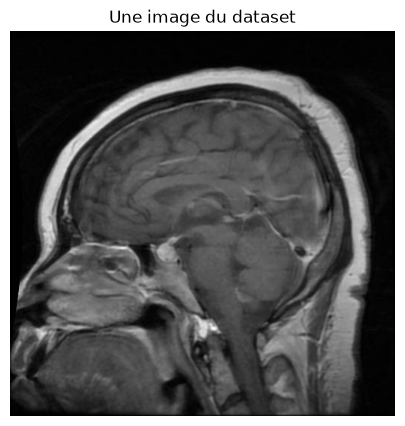

In [7]:
plt.figure(figsize=(5, 5))
plt.imshow(pixels)
plt.title("Une image du dataset")
plt.axis("off")
plt.show()

Affichage de quelques exemples de chaque dossier

random.seed(42) permet de retrouver la même sélection si rééxécution

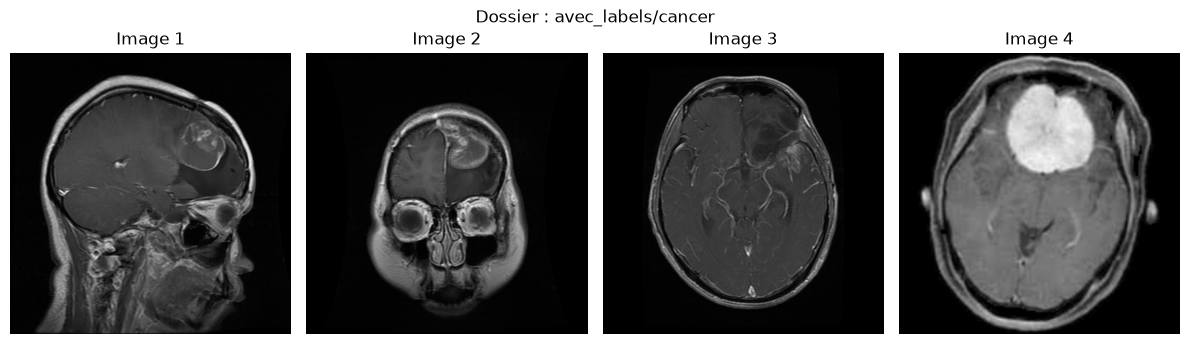

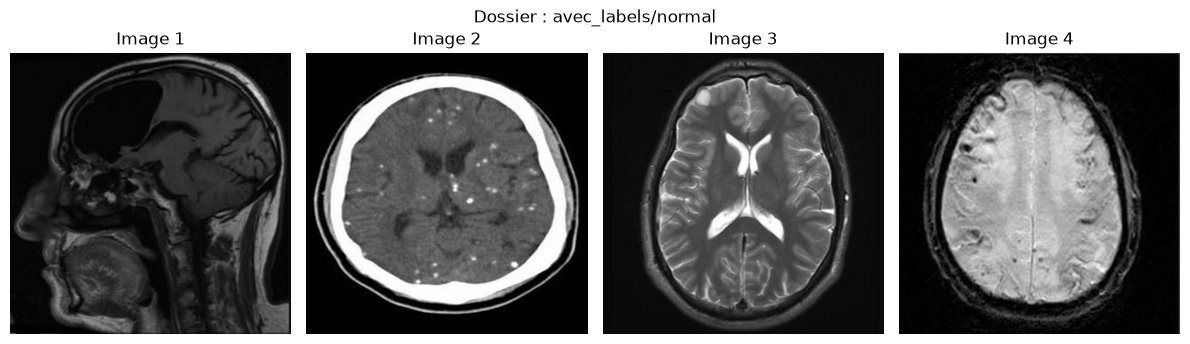

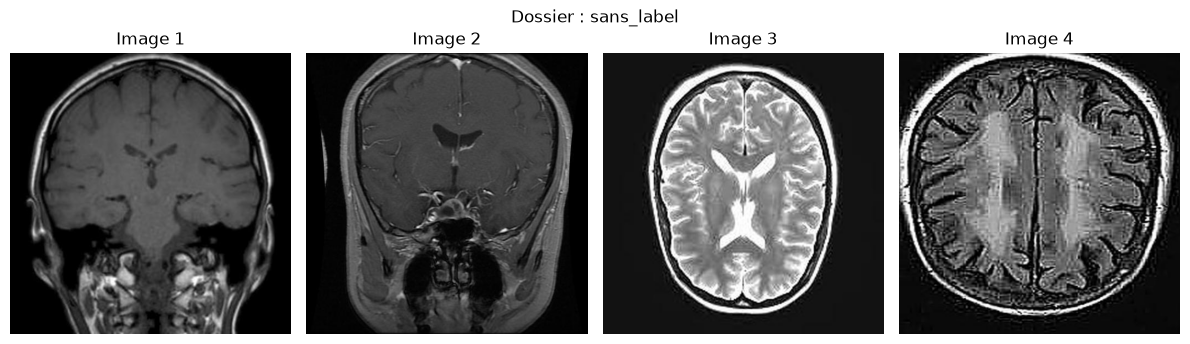

In [8]:
random.seed(42)

for dossier in dossiers:
    fichiers = sorted((dossier_dataset / dossier).glob("*.jpg"))
    exemples = random.sample(fichiers, min(4, len(fichiers)))

    plt.figure(figsize=(12, 3.5))
    for numero, chemin in enumerate(exemples, start=1):
        with Image.open(chemin) as image:
            pixels_exemple = np.array(image)

        plt.subplot(1, 4, numero)
        plt.imshow(pixels_exemple)
        plt.title(f"Image {numero}")
        plt.axis("off")

    plt.suptitle(f"Dossier : {dossier}")
    plt.tight_layout()
    plt.show()

échantillon de 100 images
Vérifications des dimensions, du mode de couleur, du nombre de canaux,
le format et la lisibilité 

In [9]:
random.seed(42)
echantillon = random.sample(chemins_images, min(100, len(chemins_images)))

print("Nombre d'images à vérifier :", len(echantillon))

Nombre d'images à vérifier : 100


Pour chaque fichier, appel de `image.load()` pour lire
ses pixels. Ses caractéristiques sont ajoutées à une liste.

In [10]:
caracteristiques = []
erreurs = []

for chemin in echantillon:
    try:
        with Image.open(chemin) as image:
            image.load()
            caracteristiques.append({
                "Fichier": chemin.name,
                "Dossier": str(chemin.parent.relative_to(dossier_dataset)),
                "Largeur": image.width,
                "Hauteur": image.height,
                "Mode": image.mode,
                "Canaux": len(image.getbands()),
                "Format": image.format,
            })
    except OSError as erreur:
        erreurs.append({"Fichier": str(chemin), "Erreur": str(erreur)})

controle = pd.DataFrame(caracteristiques)
display(controle.head())

,Fichier,Dossier,Largeur,Hauteur,Mode,Canaux,Format
0,de4a58ef-0572-499a-8b39-437d6605102e.jpg,sans_label,512,512,RGB,3,JPEG
1,1567a15d-5f22-46ca-a77c-cd88ee60b7fd.jpg,sans_label,512,512,RGB,3,JPEG
2,09316c60-86c8-4f24-934e-8d433b8b9d72.jpg,avec_labels/normal,512,512,RGB,3,JPEG
3,5674a7bf-6fe6-4c43-b574-fdd81608e18b.jpg,sans_label,512,512,RGB,3,JPEG
4,4a4822ad-22e0-4dac-a072-18fe2824cc9f.jpg,sans_label,512,512,RGB,3,JPEG


Regroupons les images pour vérifier qu'elles ont les mêmes caractéristiques

In [11]:
resume = controle.groupby(["Largeur", "Hauteur", "Mode", "Canaux"]).size()
display(resume.to_frame("Nombre d'images"))
display(controle["Format"].value_counts().to_frame("Nombre d'images"))

print("Images lisibles dans l'échantillon :", len(controle))
print("Erreurs de lecture :", len(erreurs))

if erreurs:
    display(pd.DataFrame(erreurs))

,,,,Nombre d'images
Largeur,Hauteur,Mode,Canaux,
512,512,RGB,3,100


,Nombre d'images
Format,
JPEG,100


Images lisibles dans l'échantillon : 100
Erreurs de lecture : 0


Recherche de doublons

In [12]:


images_vues = {}
doublons = []

for chemin in chemins_images:
    with Image.open(chemin) as image:
        image_rgb = image.convert("RGB")
        empreinte = hashlib.sha256(image_rgb.tobytes()).hexdigest()
        signature = (image_rgb.size, empreinte)

    if signature in images_vues:
        doublons.append((images_vues[signature], chemin))
    else:
        images_vues[signature] = chemin

print("Nombre d'images examinées :", len(chemins_images))
print("Nombre de copies supplémentaires :", len(doublons))

display(pd.DataFrame(doublons, columns=["Première image", "Copie"]))

Nombre d'images examinées : 1506
Nombre de copies supplémentaires : 96


,Première image,Copie
0,mri_dataset_brain_cancer_oc/avec_labels/normal...,mri_dataset_brain_cancer_oc/avec_labels/normal...
1,mri_dataset_brain_cancer_oc/avec_labels/normal...,mri_dataset_brain_cancer_oc/sans_label/04dd2b7...
2,mri_dataset_brain_cancer_oc/avec_labels/normal...,mri_dataset_brain_cancer_oc/sans_label/16a1699...
3,mri_dataset_brain_cancer_oc/avec_labels/normal...,mri_dataset_brain_cancer_oc/sans_label/18599c4...
4,mri_dataset_brain_cancer_oc/avec_labels/normal...,mri_dataset_brain_cancer_oc/sans_label/194106c...
...,...,...
91,mri_dataset_brain_cancer_oc/sans_label/1212636...,mri_dataset_brain_cancer_oc/sans_label/f84cb0d...
92,mri_dataset_brain_cancer_oc/avec_labels/cancer...,mri_dataset_brain_cancer_oc/sans_label/f946618...
93,mri_dataset_brain_cancer_oc/sans_label/abac225...,mri_dataset_brain_cancer_oc/sans_label/fa8ec37...
94,mri_dataset_brain_cancer_oc/sans_label/f9d60d2...,mri_dataset_brain_cancer_oc/sans_label/fcf1c2e...


regroupons e simages par dossier

In [13]:
fichiers_concernes = set()

for premiere_image, copie in doublons:
    fichiers_concernes.add(premiere_image)
    fichiers_concernes.add(copie)

dossiers_doublons = pd.Series(
    [chemin.parent.name for chemin in fichiers_concernes],
    name="Dossier"
)

classement = dossiers_doublons.value_counts()
classement = classement.reindex(
    ["sans_label", "cancer", "normal"], fill_value=0
)

display(classement.to_frame("Fichiers concernés"))

,Fichiers concernés
Dossier,
sans_label,154
cancer,8
normal,24


On effectue la recherche de doublons par dossier cette fois ci

In [14]:


for dossier in ["sans_label", "avec_labels/cancer", "avec_labels/normal"]:
    images_vues = {}
    doublons_dossier = []

    chemins = sorted((dossier_dataset / dossier).glob("*.jpg"))

    for chemin in chemins:
        with Image.open(chemin) as image:
            image_rgb = image.convert("RGB")
            empreinte = hashlib.sha256(image_rgb.tobytes()).hexdigest()
            signature = (image_rgb.size, empreinte)

        if signature in images_vues:
            doublons_dossier.append((images_vues[signature], chemin))
        else:
            images_vues[signature] = chemin

    print(f"{dossier} : {len(doublons_dossier)} copie(s) supplémentaire(s)")

    if doublons_dossier:
        display(pd.DataFrame(
            doublons_dossier,
            columns=["Première image", "Copie"]
        ))

sans_label : 64 copie(s) supplémentaire(s)


,Première image,Copie
0,mri_dataset_brain_cancer_oc/sans_label/11c7876...,mri_dataset_brain_cancer_oc/sans_label/21797d4...
1,mri_dataset_brain_cancer_oc/sans_label/01d4471...,mri_dataset_brain_cancer_oc/sans_label/3a1ca11...
2,mri_dataset_brain_cancer_oc/sans_label/3058ed0...,mri_dataset_brain_cancer_oc/sans_label/3a57247...
3,mri_dataset_brain_cancer_oc/sans_label/1d9eb25...,mri_dataset_brain_cancer_oc/sans_label/4ab4a1f...
4,mri_dataset_brain_cancer_oc/sans_label/070e468...,mri_dataset_brain_cancer_oc/sans_label/55e150d...
...,...,...
59,mri_dataset_brain_cancer_oc/sans_label/9f94cc0...,mri_dataset_brain_cancer_oc/sans_label/f5b5021...
60,mri_dataset_brain_cancer_oc/sans_label/1212636...,mri_dataset_brain_cancer_oc/sans_label/f84cb0d...
61,mri_dataset_brain_cancer_oc/sans_label/abac225...,mri_dataset_brain_cancer_oc/sans_label/fa8ec37...
62,mri_dataset_brain_cancer_oc/sans_label/f9d60d2...,mri_dataset_brain_cancer_oc/sans_label/fcf1c2e...


avec_labels/cancer : 0 copie(s) supplémentaire(s)
avec_labels/normal : 1 copie(s) supplémentaire(s)


,Première image,Copie
0,mri_dataset_brain_cancer_oc/avec_labels/normal...,mri_dataset_brain_cancer_oc/avec_labels/normal...


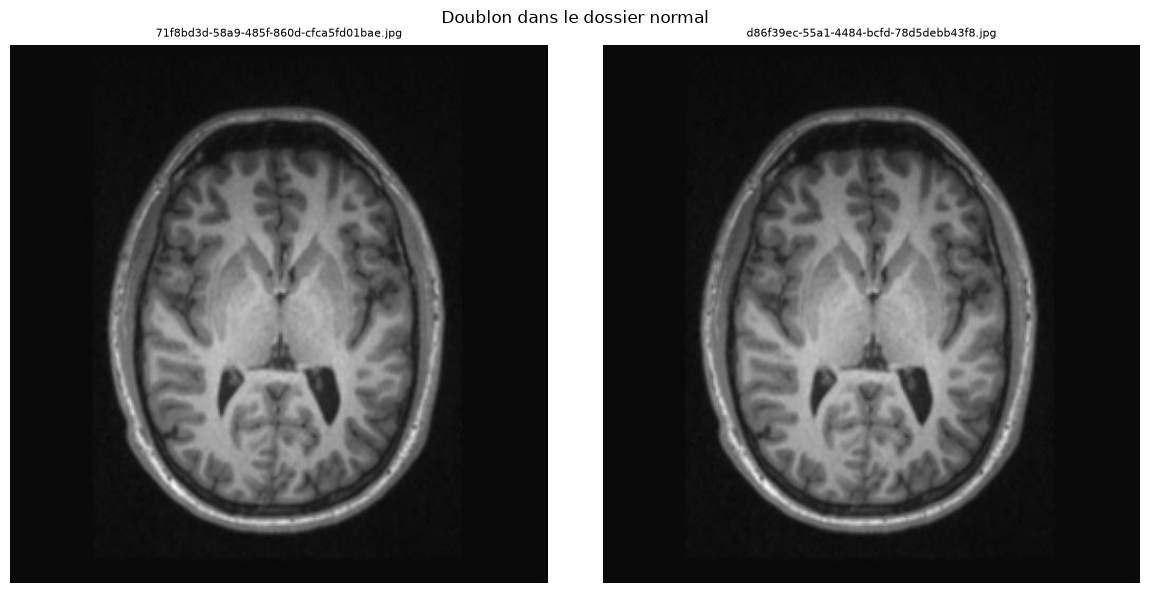

In [15]:
dossier_normal = Path("mri_dataset_brain_cancer_oc/avec_labels/normal")

fichiers = [
    "71f8bd3d-58a9-485f-860d-cfca5fd01bae.jpg",
    "d86f39ec-55a1-4484-bcfd-78d5debb43f8.jpg",
]

plt.figure(figsize=(12, 6))

for numero, nom in enumerate(fichiers, start=1):
    with Image.open(dossier_normal / nom) as image:
        plt.subplot(1, 2, numero)
        plt.imshow(image)

    plt.title(nom, fontsize=8)
    plt.axis("off")

plt.suptitle("Doublon dans le dossier normal")
plt.tight_layout()
plt.show()

Conclusion

- Le comptage donne **1 506 images JPEG** : 50 dans cancer, 50 dans normal
  et 1 406 dans sans_label.
- Les deux classes étiquetées sont équilibrées. 
- Le dossier sans label contient **six images de plus** qque l'enoncé
- Les **100 images contrôlées** mesurent **512 × 512 pixels** et sont stockées
  en **RGB, avec trois canaux**.
- Aucune erreur de lecture n'a été rencontrée dans cet échantillon.
- Les images montrent différentes orientations de coupe et différents cadrages.
- La place occupée par le cerveau, le contraste et la netteté apparente varient.
- Les exemples apparaissent principalement en niveaux de gris malgré le stockage RGB.
- Une même taille de 512 × 512 pixels ne garantit pas une qualité visuelle uniforme.
- Le data set contient des doublons:
  - 96 au total sur le set global
  - 1 dans le dossier lablélisé: Normal
  
  --> Ces doublons seront à traiter

Traitement des doublons

In [16]:
nombre_images_avant = len(chemins_images)

# Récupérer les chemins des copies supplémentaires.
copies_a_ecarter = {
    copie for premiere_image, copie in doublons
}

# Conserver uniquement la première occurrence de chaque image.
chemins_images = [
    chemin for chemin in chemins_images
    if chemin not in copies_a_ecarter
]

print("Images avant filtrage :", nombre_images_avant)
print("Copies écartées :", nombre_images_avant - len(chemins_images))
print("Images conservées pour l'étape 2 :", len(chemins_images))

Images avant filtrage : 1506
Copies écartées : 96
Images conservées pour l'étape 2 : 1410


## Etape 2: Prétraitement et extraction des features


Choix d'une version préentrainé de ResNet18: IMAGENET1K_V1
définition de la focntion prétraitement qui réalisera le redimensionnement des images, le recadrage, la conversion et la normalisation


In [17]:


poids = models.ResNet18_Weights.IMAGENET1K_V1
pretraitement = poids.transforms()
print(pretraitement)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


Application de "pretraitement" à chaque image du dataset
Stockage du resultat dans la liste images_preparees


In [18]:
images_preparees = []

for chemin in chemins_images:
    image = read_image(str(chemin), mode=ImageReadMode.RGB)
    images_preparees.append(pretraitement(image))

print("Nombre d'images préparées :", len(images_preparees))
print("Forme d'une image préparée :", tuple(images_preparees[0].shape))
print("Type des valeurs :", images_preparees[0].dtype)

Nombre d'images préparées : 1410
Forme d'une image préparée : (3, 224, 224)
Type des valeurs : torch.float32


Chargement de ResNet avec le poids préentrainé précédement choisi
Gel des couches convutionelles avec `requires_grad = False` (cela gele tous les paramètres du modele, y compris les couches convutionelles donc cela repond à notre bespoin)

On prépare le modèle pour renvoyer les 512 nombres décrivant l’image avec identity(), puis modele.eval() pour utiliser le modele déjà entrainé

pui son verifie que les couches sont bien gelées en verifiant les paramètre entrainabels

In [19]:
modele = models.resnet18(weights=poids)

for parametre in modele.parameters():
    parametre.requires_grad = False

modele.fc = torch.nn.Identity()
modele.eval()

print("Nombre de paramètres entraînables :", sum(
    parametre.numel() for parametre in modele.parameters() if parametre.requires_grad
))

Nombre de paramètres entraînables : 0


Extractions des embeddings des images préparés:
- On traite les images préparées par lots de 16 : pour chaque image, le modèle crée un vecteur de 512 nombres décrivant l’image.
- On ajoute avec append() chaque lot de 16 vecteurs dans blocs_features.
- Après la boucle, on concatène avec np.concatenate() les blocs en un tableau unique.

In [20]:
taille_lot = 16
blocs_features = []

for debut in range(0, len(images_preparees), taille_lot):
    images_lot = images_preparees[debut:debut + taille_lot]
    lot = torch.stack(images_lot)
    features_lot = modele(lot).numpy()
    blocs_features.append(features_lot)

    nombre_traite = debut + len(images_lot)
    if debut % (taille_lot * 10) == 0 or nombre_traite == len(images_preparees):
        print(f"Images traitées : {nombre_traite} / {len(images_preparees)}")

matrice_features = np.concatenate(blocs_features, axis=0)
print("Forme de la matrice de features :", matrice_features.shape)

Images traitées : 16 / 1410
Images traitées : 176 / 1410


KeyboardInterrupt: 


Transformation de matrice_features en tableau pandas nommé features avec les colonnes de features numériques nommées feature_000 à feature_511.

La premiere colonne du tableau contient le chemin relatif de l'image

In [ ]:
colonnes_features = [f"feature_{numero:03d}" for numero in range(512)]
features = pd.DataFrame(matrice_features, columns=colonnes_features)
features.insert(0, "chemin", [
    chemin.relative_to(dossier_dataset).as_posix() for chemin in chemins_images
])

print("Forme du tableau :", features.shape)
display(features.head())

Forme du tableau : (1410, 513)


,chemin,feature_000,feature_001,feature_002,feature_003,feature_004,feature_005,feature_006,feature_007,feature_008,...,feature_502,feature_503,feature_504,feature_505,feature_506,feature_507,feature_508,feature_509,feature_510,feature_511
0,avec_labels/cancer/05340cd4-3bb2-459d-9937-bf2...,0.182118,0.333518,1.282342,0.834789,1.378281,0.484790,2.094169,0.158858,0.419732,...,0.036741,0.564865,0.443068,0.854441,1.457598,0.201099,0.316057,0.211322,0.390608,0.708158
1,avec_labels/cancer/0c6f3641-60d9-4a76-abe5-de8...,2.266326,1.162453,1.918435,2.012136,1.693995,0.137189,1.577458,0.216767,1.499850,...,0.310547,0.267448,3.290416,0.624881,1.411666,1.611988,0.535143,0.598020,0.040257,1.162966
2,avec_labels/cancer/0f718241-8f63-4b55-81ce-315...,4.595700,1.165719,0.881030,0.903633,1.555227,0.086425,1.360634,0.000000,1.339879,...,0.452656,0.895471,1.856983,0.600913,2.108837,2.697287,0.648695,1.338270,0.041187,0.565739
3,avec_labels/cancer/11a7a426-4806-401e-98b2-b96...,1.982301,1.395936,1.432251,0.519939,0.580916,0.160166,3.397490,0.003394,2.662047,...,1.137100,0.316018,4.567581,1.865795,1.694037,1.388204,0.114191,0.154368,1.244824,1.034642
4,avec_labels/cancer/1c043dbb-4623-4769-8e5e-022...,2.520188,0.711255,0.919493,1.350703,2.717374,0.066807,1.882675,0.078474,0.076435,...,0.355171,0.073457,1.313526,0.581309,0.367498,0.784860,0.410580,1.877233,0.000000,1.895125


## Etape 3: modélisation non supervisée



Séparation avant les transformations : train, validation et test forts ; train et test sans label.

In [ ]:
masque_fort = features["chemin"].str.startswith("avec_labels/")
masque_sans_label = features["chemin"].str.startswith("sans_label/")

donnees_fortes = features.loc[masque_fort].copy()
donnees_fortes["label_fort"] = donnees_fortes["chemin"].str.split("/").str[1]
donnees_sans_label = features.loc[masque_sans_label].copy()

# Réserver le test fort, puis la validation forte.
fortes_train, fortes_test = train_test_split(
    donnees_fortes,
    test_size=0.2,
    stratify=donnees_fortes["label_fort"],
    random_state=42,
)
fortes_train, fortes_validation = train_test_split(
    fortes_train,
    test_size=0.2,
    stratify=fortes_train["label_fort"],
    random_state=42,
)

# Les images sans label sont séparées avant leur labellisation faible.
sans_label_train, sans_label_test = train_test_split(
    donnees_sans_label,
    test_size=0.2,
    random_state=42,
)

print("Train fort :", len(fortes_train))
print("Validation forte :", len(fortes_validation))
print("Test fort :", len(fortes_test))
print("Train sans label :", len(sans_label_train))
print("Test sans label :", len(sans_label_test))


Standardisation des features avec StandardScaler

Modification : standardisation apprise uniquement sur le train.

In [ ]:
# Seules les features d'entraînement servent à apprendre les paramètres.
X_features = pd.concat([
    fortes_train[colonnes_features],
    sans_label_train[colonnes_features],
], ignore_index=True)

standardisation = StandardScaler()
X_standardise = standardisation.fit_transform(X_features)

print("Forme des features d'entraînement standardisées :", X_standardise.shape)
display(pd.DataFrame(X_standardise, columns=colonnes_features).head())


Réducitond es dimensions en utilisant la fonction fit_transform de PCA

Modification : PCA apprise sur le train ; validation et tests transformés sans réapprentissage.

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca_entrainement = pca.fit_transform(X_standardise)

# Séparer les coordonnées des deux ensembles d'entraînement.
X_fort_pca = X_pca_entrainement[:len(fortes_train)]
X_pca = X_pca_entrainement[len(fortes_train):]

# Appliquer les paramètres appris à la validation et aux tests.
X_validation_pca = pca.transform(standardisation.transform(
    fortes_validation[colonnes_features]
))
X_fort_test_pca = pca.transform(standardisation.transform(
    fortes_test[colonnes_features]
))
X_test_pca = pca.transform(standardisation.transform(
    sans_label_test[colonnes_features]
))

print("PCA train fort :", X_fort_pca.shape)
print("PCA train sans label :", X_pca.shape)
print("PCA validation forte :", X_validation_pca.shape)
print("PCA test fort :", X_fort_test_pca.shape)
print("PCA test sans label :", X_test_pca.shape)


Réalisation du clustering avec K-Means

- n_clusters=2 pour la spération en deux groupes, comme pour le dataset labélisé
- random_state=42 pour pouvori reproduirele clustering.

Modification : K-Means entraîné uniquement sur le train sans label.

In [ ]:
# X_pca contient uniquement le train sans label.
kmeans = KMeans(n_clusters=2, random_state=42)
groupes_kmeans_sans_label = kmeans.fit_predict(X_pca)

display(pd.Series(groupes_kmeans_sans_label).value_counts().sort_index().to_frame("Nombre d'images"))

Graphique illustrant les coordonées des images

Chaque point représente une image, placée selon ses deux coordonnées PCA. Sa couleur indique le groupe attribué par K-Means.

Modification : graphique du train sans label.

In [ ]:
plt.figure(figsize=(8, 6))

for groupe in [0, 1]:
    selection = groupes_kmeans_sans_label == groupe
    plt.scatter(X_pca[selection, 0], X_pca[selection, 1],
                s=15, alpha=0.6, label=f"Groupe {groupe}")

plt.xlabel("Coordonnée PCA 1")
plt.ylabel("Coordonnée PCA 2")
plt.title("K-Means : deux groupes d'images sans label")
plt.legend()
plt.tight_layout()
plt.show()

K-Means répartit les images en deux groupes, principalement séparés par l'abscisse PCA (gauche vs droite). Les groupes présentent une dispersion interne. Cette représentation montre des différences entre les images, sans pour autant identifier chaque groupe comme étant: « normal » et « cancer ».

Réalisation du clustering avec DBSCAN

Choix de neuf combinaisaon à tester pour visualiser ensutie les resultats:
- eps (rayon du voisinage ): 0.5, 1.0, 2.0
- et repectivement min_samples (nombre minimum de points dans ce voisinage): 3, 5, 10.  ;

Chaque résultat est conservé dans essais_dbscan avec ses paramètres, ses numéros de groupes, le nombre de groupes et le nombre d'images hors groupe (-1).

Modification : DBSCAN entraîné uniquement sur le train sans label.

In [ ]:
# Les neuf essais utilisent uniquement le train sans label.
essais_dbscan = []

for eps in [0.5, 1.0, 2.0]:
    for min_samples in [3, 5, 10]:
        dbscan_essai = DBSCAN(eps=eps, min_samples=min_samples)
        groupes_essai = dbscan_essai.fit_predict(X_pca)
        nombre_groupes_essai = len(set(groupes_essai) - {-1})
        nombre_hors_groupe_essai = int((groupes_essai == -1).sum())

        essais_dbscan.append({
            "eps": eps,
            "min_samples": min_samples,
            "groupes": groupes_essai,
            "nombre_groupes": nombre_groupes_essai,
            "nombre_hors_groupe": nombre_hors_groupe_essai,
        })

        print(f"eps={eps}, min_samples={min_samples} : "
              f"{nombre_groupes_essai} groupe(s), "
              f"{nombre_hors_groupe_essai} image(s) hors groupe")


Affichage d'un graphique pour chaque essai de paramètre avec DBSCAN: Une couleur représente chaque groupe ; les points hors groupe (`-1`) sont affichés en gris.



In [ ]:
for essai in essais_dbscan:
    groupes_essai = essai["groupes"]
    plt.figure(figsize=(8, 6))

    for groupe in sorted(set(groupes_essai)):
        selection = groupes_essai == groupe
        if groupe == -1:
            plt.scatter(X_pca[selection, 0], X_pca[selection, 1],
                        s=20, color="gray", label="Hors groupe (-1)")
        else:
            plt.scatter(X_pca[selection, 0], X_pca[selection, 1],
                        s=15, alpha=0.6, label=f"Groupe {groupe}")

    plt.xlabel("Coordonnée PCA 1")
    plt.ylabel("Coordonnée PCA 2")
    plt.title(
        f"DBSCAN : eps={essai['eps']}, min_samples={essai['min_samples']}\n"
        f"{essai['nombre_groupes']} groupe(s), "
        f"{essai['nombre_hors_groupe']} images hors groupe"
    )
    plt.tight_layout()
    plt.show()

Avec les paramètres testés, DBSCAN produit un nombre de groupes différent des deux groupes demandés, ainsi que des images hors groupe. Je l’écarte donc pour la labellisation faible et je conserve K-Means, qui répartit les images en deux groupes.

calcul du score ARI de K-Means

Modification : ARI calculé sur la validation forte.

In [ ]:
# Évaluer les regroupements sur la validation forte réservée.
labels_reference = fortes_validation["label_fort"].to_numpy()
groupes_kmeans_forts = kmeans.predict(X_validation_pca)
ari_kmeans = adjusted_rand_score(labels_reference, groupes_kmeans_forts)

scores_ari = pd.DataFrame({
    "Méthode": ["K-Means"],
    "ARI sur la validation forte": [ari_kmeans],
})
display(scores_ari)


Labels faibles du train issus de K-Means ; labels du test prédits sans réentraînement. Les labels forts restent séparés.

In [ ]:
faibles_train = sans_label_train.copy()
faibles_train["label_faible"] = groupes_kmeans_sans_label

faibles_test = sans_label_test.copy()
faibles_test["label_faible"] = kmeans.predict(X_test_pca)

# Conserver le tableau des labels faibles, sans le mélanger aux labels forts.
donnees_faibles = pd.concat([faibles_train, faibles_test]).sort_index()

print("Méthode utilisée pour les labels faibles : K-Means")
print("Images fortement labellisées, conservées séparément :", len(donnees_fortes))
print("Images faiblement labellisées :", len(donnees_faibles))
print("Train faible :", len(faibles_train))
print("Test faible :", len(faibles_test))
display(donnees_faibles[["chemin", "label_faible"]].head())
display(donnees_faibles["label_faible"].value_counts().sort_index().to_frame("Nombre d'images"))


## Étape 4 : entraînement du CNN



Réutilisation des ensembles train, validation et test réservés à l’étape 3. Affichage des effectifs par label.

In [ ]:
# Réutiliser les ensembles réservés à l’étape 3.
effectifs_faibles = pd.DataFrame({
    "Entraînement faible": faibles_train["label_faible"].value_counts(),
    "Test faible": faibles_test["label_faible"].value_counts(),
}).reindex([0, 1]).fillna(0).astype(int)

effectifs_forts = pd.DataFrame({
    "Entraînement fort": fortes_train["label_fort"].value_counts(),
    "Validation forte": fortes_validation["label_fort"].value_counts(),
    "Test fort": fortes_test["label_fort"].value_counts(),
}).reindex(["normal", "cancer"]).fillna(0).astype(int)

display(effectifs_faibles)
display(effectifs_forts)


Mise en forme des donnes pour le CNN:
- On associe chaque image à son étiquette.
- On prépare les chargeurs qui fourniront le couple image/etiquette au CNN

Modification : ajout du chargeur de validation forte.

In [ ]:
faibles_train["cible"] = faibles_train["label_faible"].astype(int)
faibles_test["cible"] = faibles_test["label_faible"].astype(int)
fortes_train["cible"] = fortes_train["label_fort"].map({"normal": 0, "cancer": 1})
fortes_test["cible"] = fortes_test["label_fort"].map({"normal": 0, "cancer": 1})
fortes_validation["cible"] = fortes_validation["label_fort"].map({"normal": 0, "cancer": 1})

taille_lot_etape4 = 16
epoques_faibles = 5
epoques_fortes = 5
taux_apprentissage = 0.001
appareil_etape4 = torch.device("cuda" if torch.cuda.is_available() else "cpu")

positions_images = {
    chemin.relative_to(dossier_dataset).as_posix(): position
    for position, chemin in enumerate(chemins_images)
}

def creer_chargeur(tableau, melanger):
    images = torch.stack([
        images_preparees[positions_images[chemin]]
        for chemin in tableau["chemin"]
    ])
    cibles = torch.tensor(tableau["cible"].to_numpy(), dtype=torch.long)
    dataset = TensorDataset(images, cibles)
    return DataLoader(
        dataset,
        batch_size=taille_lot_etape4,
        shuffle=melanger,
        generator=torch.Generator().manual_seed(42),
    )

chargeur_faible = creer_chargeur(faibles_train, melanger=True)
chargeur_test_faible = creer_chargeur(faibles_test, melanger=False)
chargeur_fort = creer_chargeur(fortes_train, melanger=True)
chargeur_validation = creer_chargeur(fortes_validation, melanger=False)
chargeur_test = creer_chargeur(fortes_test, melanger=False)

print("Lots d'entraînement faible :", len(chargeur_faible))
print("Lots de test faible :", len(chargeur_test_faible))
print("Lots d'entraînement fort :", len(chargeur_fort))
print("Lots de validation forte :", len(chargeur_validation))
print("Lots de test fort :", len(chargeur_test))
print("Appareil utilisé :", appareil_etape4)


Creation de deux CNN:
- Un pour l'entraienment semi-supervisé
- un pour l'entrainement supervisé

On utilise le même poids (utilisé en etape 2)

In [ ]:
def creer_cnn():
    torch.manual_seed(42)
    cnn = models.resnet18(weights=poids)
    for parametre in cnn.parameters():
        parametre.requires_grad = False
    cnn.fc = torch.nn.Linear(cnn.fc.in_features, 2)
    return cnn.to(appareil_etape4)

modele_semi = creer_cnn()
modele_supervise = creer_cnn()
fonction_perte = torch.nn.CrossEntropyLoss()

optimiseur_semi = torch.optim.Adam(
    modele_semi.fc.parameters(), lr=taux_apprentissage
)
optimiseur_supervise = torch.optim.Adam(
    modele_supervise.fc.parameters(), lr=taux_apprentissage
)

for nom, cnn in [("Semi-supervisé", modele_semi), ("Supervisé", modele_supervise)]:
    print(nom, ": paramètres entraînables =", sum(
        parametre.numel() for parametre in cnn.parameters()
        if parametre.requires_grad
    ))


Creation de 2 fonctions:
- entrainer_cnn qui entraine le CNN en ajustant le poids de la couche finale et qui affiche la perte moyenne à chaque époque
- evaluer_cnn fera les prédictions sur un test sans modifier les poids. L'evaluation se fait avec l'accuracy, le F1 score, la matrice de confusion, la précision, du rappel et du F2 pour le label 1


In [ ]:
def entrainer_cnn(cnn, chargeur, optimiseur, nombre_epoques):
    chargeur.generator.manual_seed(42)
    pertes = []

    for epoque in range(nombre_epoques):
        cnn.eval()
        cnn.fc.train()
        perte_totale = 0.0

        for images_lot, cibles_lot in chargeur:
            images_lot = images_lot.to(appareil_etape4)
            cibles_lot = cibles_lot.to(appareil_etape4)

            optimiseur.zero_grad()
            sorties = cnn(images_lot)
            perte = fonction_perte(sorties, cibles_lot)
            perte.backward()
            optimiseur.step()
            perte_totale += perte.item() * len(cibles_lot)

        perte_moyenne = perte_totale / len(chargeur.dataset)
        pertes.append(perte_moyenne)
        print(f"Époque {epoque + 1}/{nombre_epoques} : perte = {perte_moyenne:.4f}")

    return pertes

def evaluer_cnn(cnn, chargeur):
    cnn.eval()
    matrice = np.zeros((2, 2), dtype=int)

    with torch.no_grad():
        for images_lot, cibles_lot in chargeur:
            sorties = cnn(images_lot.to(appareil_etape4))
            predictions = sorties.argmax(dim=1).cpu()
            for vraie_classe, classe_predite in zip(
                cibles_lot.tolist(), predictions.tolist()
            ):
                matrice[vraie_classe, classe_predite] += 1

    vrais_negatifs, faux_positifs, faux_negatifs, vrais_positifs = matrice.ravel()
    denominateur_f1 = 2 * vrais_positifs + faux_positifs + faux_negatifs
    denominateur_precision = vrais_positifs + faux_positifs
    denominateur_rappel = vrais_positifs + faux_negatifs
    denominateur_f2 = 5 * vrais_positifs + 4 * faux_negatifs + faux_positifs
    mesures = {
        "Accuracy": (vrais_negatifs + vrais_positifs) / matrice.sum(),
        "F1": 2 * vrais_positifs / denominateur_f1 if denominateur_f1 > 0 else 0.0,
        "Précision": vrais_positifs / denominateur_precision if denominateur_precision > 0 else 0.0,
        "Rappel": vrais_positifs / denominateur_rappel if denominateur_rappel > 0 else 0.0,
        "F2": 5 * vrais_positifs / denominateur_f2 if denominateur_f2 > 0 else 0.0,
    }
    return mesures, matrice

print("Fonctions d'entraînement et d'évaluation définies.")


comparaison de quatre configurations d'hyperparamètres: taux 0,0001 ou 0,001 ; 5 ou 10 époques fortes, après 5 époques faibles. La validation est réservée à l’étape 3; le test fort ne sert pas à la sélection. 
Le tableau affiche les métriques de validation pour la classe cancer. Le meilleur F2 détermine les paramètres retenus, puis modele_semi et son optimiseur sont recréés pour les entraînements suivants.

Modification : validation réutilisée sans nouveau split.

In [ ]:
# Réutiliser le train et la validation réservés à l’étape 3.
resultats_recherche = []

for taux_essai in [0.0001, 0.001]:
    for epoques_essai in [5, 10]:
        print(f"Essai : taux = {taux_essai}, époques fortes = {epoques_essai}")

        # Chaque essai repart des mêmes poids pré-entraînés.
        modele_essai = creer_cnn()
        optimiseur_essai = torch.optim.Adam(
            modele_essai.fc.parameters(), lr=taux_essai
        )

        entrainer_cnn(
            modele_essai, chargeur_faible, optimiseur_essai, epoques_faibles
        )
        entrainer_cnn(
            modele_essai, chargeur_fort, optimiseur_essai, epoques_essai
        )
        mesures_validation, _ = evaluer_cnn(modele_essai, chargeur_validation)

        resultats_recherche.append({
            "taux_apprentissage": taux_essai,
            "epoques_fortes": epoques_essai,
            **mesures_validation,
        })

tableau_recherche = pd.DataFrame(resultats_recherche)
display(tableau_recherche.rename(columns={
    "Accuracy": "Accuracy validation",
    "F1": "F1 cancer validation",
    "Précision": "Précision cancer validation",
    "Rappel": "Rappel cancer validation",
    "F2": "F2 cancer validation",
}).round(4))

meilleurs_parametres = tableau_recherche.loc[tableau_recherche["F2"].idxmax()]
taux_apprentissage_semi = float(meilleurs_parametres["taux_apprentissage"])
epoques_fortes_semi = int(meilleurs_parametres["epoques_fortes"])

# Préparer le modèle final pour l'entraînement faible, puis fort.
modele_semi = creer_cnn()
optimiseur_semi = torch.optim.Adam(
    modele_semi.fc.parameters(), lr=taux_apprentissage_semi
)

print("Taux retenu pour le semi-supervisé :", taux_apprentissage_semi)
print("Époques fortes retenues :", epoques_fortes_semi)
print("Meilleur F2 cancer sur la validation :", round(meilleurs_parametres["F2"], 3))


Entrainement sur les labels faibles

Modification pour les hyperparamètres : entraînement faible avec le taux retenu par la recherche et le CNN semi-supervisé recréé.

In [ ]:
pertes_faibles = entrainer_cnn(
    modele_semi, chargeur_faible, optimiseur_semi, epoques_faibles
)
mesures_faibles, confusion_faibles = evaluer_cnn(
    modele_semi, chargeur_test_faible
)

display(pd.DataFrame(
    [mesures_faibles], index=["Test faible : groupes K-Means"]
).rename(columns={
    "F1": "F1 groupe 1",
    "Précision": "Précision groupe 1",
    "Rappel": "Rappel groupe 1",
    "F2": "F2 groupe 1",
}).round(3))


Puis entraienemnt sur les données fortes
puis evaluaiton

Modification pour les hyperparamètres : poursuite du même CNN sur tout `fortes_train`, avec le taux et le nombre d’époques fortes retenus.

In [ ]:
pertes_semi = entrainer_cnn(
    modele_semi, chargeur_fort, optimiseur_semi, epoques_fortes_semi
)
mesures_semi, confusion_semi = evaluer_cnn(modele_semi, chargeur_test)

display(pd.DataFrame(
    [mesures_semi], index=["Semi-supervisé : faible puis fort"]
).rename(columns={
    "F1": "F1 cancer",
    "Précision": "Précision cancer",
    "Rappel": "Rappel cancer",
    "F2": "F2 cancer",
}).round(3))


Entrainement du modele_supervisé sur les données fortes uniquement
puis evaluation sur les mêmes metriques que l'entaienement semi-supervisé

In [ ]:
pertes_supervise = entrainer_cnn(
    modele_supervise, chargeur_fort, optimiseur_supervise, epoques_fortes
)
mesures_supervise, confusion_supervise = evaluer_cnn(
    modele_supervise, chargeur_test
)

display(pd.DataFrame(
    [mesures_supervise], index=["Supervisé : fort uniquement"]
).rename(columns={
    "F1": "F1 cancer",
    "Précision": "Précision cancer",
    "Rappel": "Rappel cancer",
    "F2": "F2 cancer",
}).round(3))


Comparaison de la methode supervisé et de la methode semi supervisé

Modification pour les hyperparamètres : comparaison du semi-supervisé avec les paramètres sélectionnés au supervisé avec ses paramètres actuels.

In [ ]:
comparaison_etape4 = pd.DataFrame(
    [mesures_semi, mesures_supervise],
    index=["Semi-supervisé : faible puis fort", "Supervisé : fort uniquement"],
).rename(columns={
    "F1": "F1 cancer",
    "Précision": "Précision cancer",
    "Rappel": "Rappel cancer",
    "F2": "F2 cancer",
})
display(comparaison_etape4.round(3))

matrices_etape4 = [confusion_semi, confusion_supervise]
titres_etape4 = ["Faible puis fort", "Fort uniquement"]
maximum_effectifs = max(matrice.max() for matrice in matrices_etape4)
figure, axes = plt.subplots(1, 2, figsize=(9, 4))

for axe, matrice, titre in zip(axes, matrices_etape4, titres_etape4):
    axe.imshow(matrice, cmap="Blues", vmin=0, vmax=maximum_effectifs)
    axe.set_xticks([0, 1], ["normal", "cancer"])
    axe.set_yticks([0, 1], ["normal", "cancer"])
    axe.set_xlabel("Classe prédite")
    axe.set_ylabel("Classe connue")
    axe.set_title(titre)

    for ligne in range(2):
        for colonne in range(2):
            couleur = "white" if matrice[ligne, colonne] > maximum_effectifs / 2 else "black"
            axe.text(
                colonne, ligne, str(matrice[ligne, colonne]),
                ha="center", va="center", color=couleur
            )

plt.tight_layout()
plt.show()

ecart_f1 = mesures_semi["F1"] - mesures_supervise["F1"]
print(f"Écart de F1 cancer (semi-supervisé - supervisé) : {ecart_f1:+.3f}")

if ecart_f1 > 0:
    print("Sur ce test, le modèle semi-supervisé obtient un F1 cancer supérieur.")
elif ecart_f1 < 0:
    print("Sur ce test, le modèle supervisé obtient un F1 cancer supérieur.")
else:
    print("Sur ce test, les deux modèles obtiennent le même F1 cancer.")


In [ ]:
duree_notebook = time.perf_counter() - debut_notebook

print(f"Durée totale : {duree_notebook:.1f} secondes")
print(f"Soit : {duree_notebook / 60:.2f} minutes")

Durée totale : 280.1 secondes
Soit : 4.67 minutes


Le fait d'avoir peu d'images non labelisées et beaucoup d'images labelisées justifie le fait de tester un entrainement semi-supervisé.
Cependant, les tests démontrent ici que le CNN est plus performant en entrainement supervisé. Dans cette configuration et sur ce test, le semi-supervisé n’apporte pas d’amélioration

Etablissement du temps nécessaire pour lire, prétraiter et attribuer un label à 1 000 images avec le CNN supervisé déjà entraîné. Les images sont traitées par lots de 16. Elle affiche la durée mesurée et une estimation pour 4 millions d’images, en supposant une vitesse comparable sur la même machine. L’entraînement n’est pas inclus.

In [ ]:
chemins_mesure = donnees_sans_label["chemin"].sample(
    n=min(1000, len(donnees_sans_label)),
    random_state=42,
).tolist()

modele_supervise.eval()
labels_predits_mesure = []

debut_labellisation = time.perf_counter()

with torch.no_grad():
    for debut in range(0, len(chemins_mesure), 16):
        chemins_lot = chemins_mesure[debut:debut + 16]
        images_lot = []

        for chemin in chemins_lot:
            image = read_image(
                str(dossier_dataset / chemin),
                mode=ImageReadMode.RGB,
            )
            images_lot.append(pretraitement(image))

        lot = torch.stack(images_lot).to(appareil_etape4)
        predictions = modele_supervise(lot).argmax(dim=1)
        labels_predits_mesure.extend(predictions.cpu().tolist())

duree_labellisation = time.perf_counter() - debut_labellisation
nombre_images = len(labels_predits_mesure)

heures_estimees = (
    duree_labellisation / nombre_images * 4_000_000 / 3600
)

print("Machine utilisée :", appareil_etape4)
print("Nombre d'images traitées :", nombre_images)
print(f"Durée mesurée : {duree_labellisation:.1f} secondes")
print(f"Estimation pour 4 millions : {heures_estimees:.1f} heures")

Machine utilisée : cpu
Nombre d'images traitées : 1000
Durée mesurée : 34.9 secondes
Estimation pour 4 millions : 38.8 heures
